# 01 — Data Pipeline: EuroSAT Loading, Visualization & Spatial Block Split

In [1]:
import sys, os
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device, plot_class_distribution, plot_sample_grid
from src.dataset import load_eurasat, naive_random_split, block_split, EUROSAT_CLASSES

SEED = 42
set_seed(SEED)
device = get_device()

DATA_ROOT = "../data/raw"
PROCESSED_DIR = "../data/processed"
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Device:", device)
print("Classes:", EUROSAT_CLASSES)

Device: cpu
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 1. Load EuroSAT

In [2]:
eurosat = load_eurasat(root=DATA_ROOT, download=True)

labels = np.array([lab for _, lab in eurosat.samples])
print(f"Total tiles: {len(eurosat)}")
print(f"Label range: {labels.min()}–{labels.max()}  (expect 0–9 for 10 classes)")

Total tiles: 27000
Label range: 0–9  (expect 0–9 for 10 classes)


## 2.visualize the data 

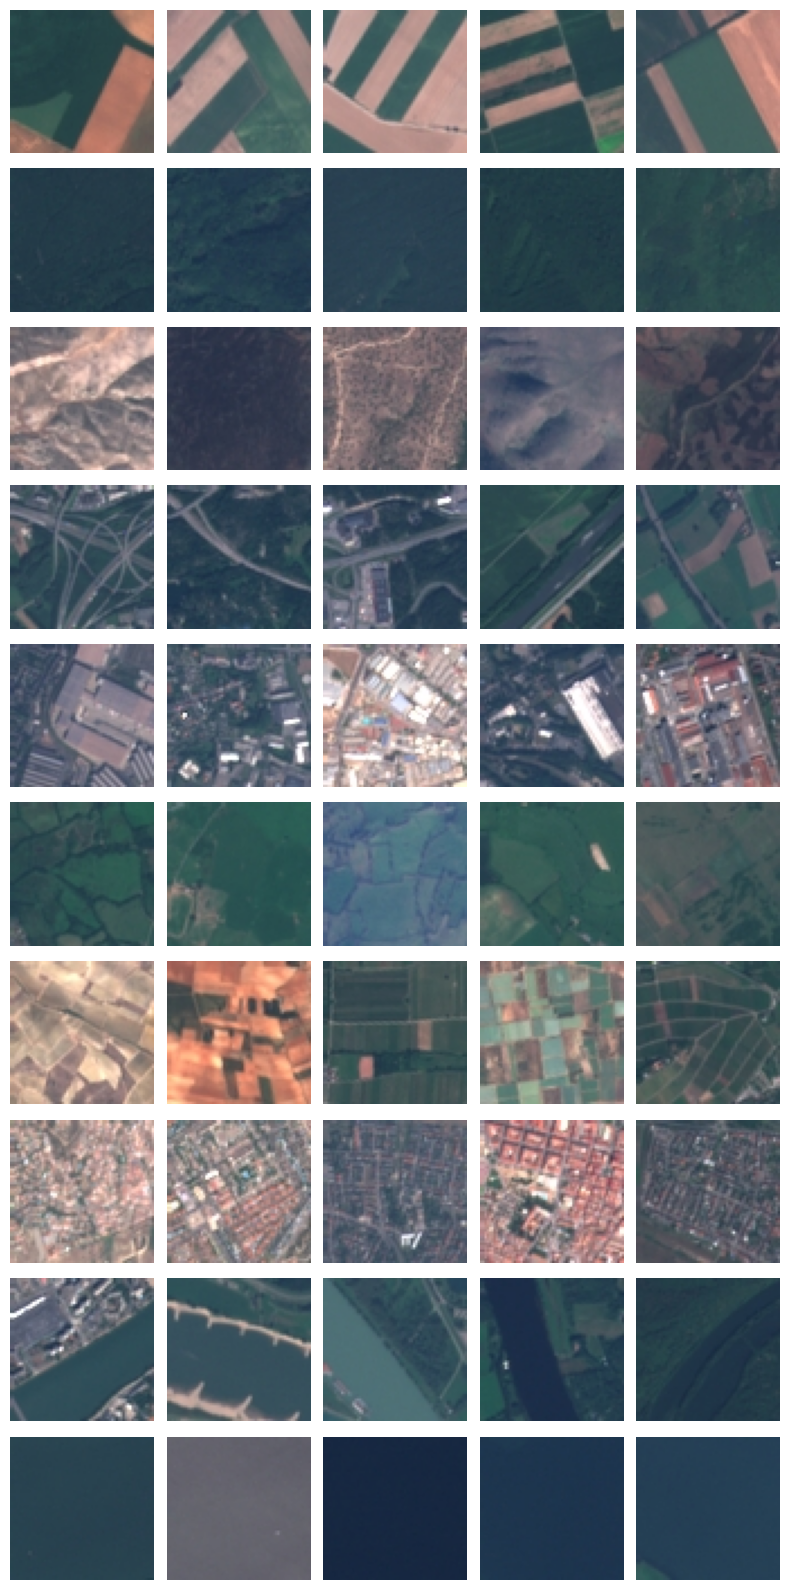

In [3]:
sample_images = [np.array(eurosat[i][0]) for i in range(0, len(eurosat), max(1, len(eurosat)//300))]
sample_labels = [eurosat[i][1] for i in range(0, len(eurosat), max(1, len(eurosat)//300))]

fig = plot_sample_grid(sample_images, sample_labels, EUROSAT_CLASSES, n_per_class=5)
plt.show()

**2b. Class distribution**

c:\Users\anshi\Celebal_Technology_Assignment\satellite-landuse-classifier\notebooks\..\src\utils.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45, ha="right")


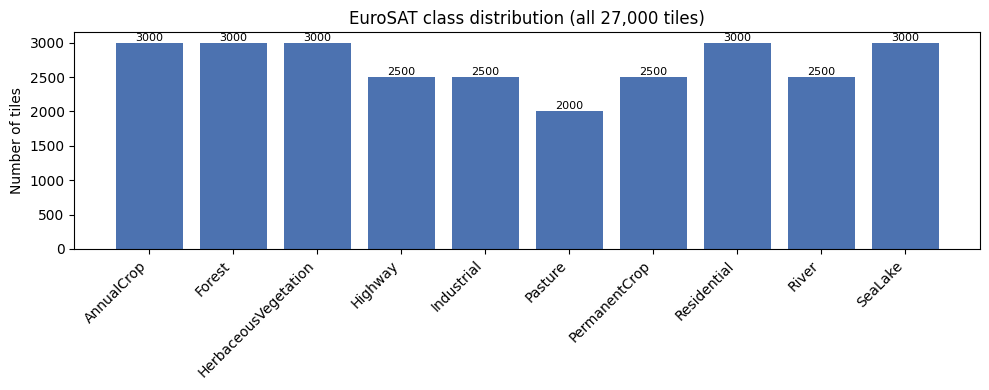

Min class count: 2000  | Max class count: 3000  | Imbalance ratio: 1.5


In [4]:
fig = plot_class_distribution(labels, EUROSAT_CLASSES, title="EuroSAT class distribution (all 27,000 tiles)")
plt.show()

counts = np.bincount(labels)
print("Min class count:", counts.min(), " | Max class count:", counts.max(),
      " | Imbalance ratio:", round(counts.max() / counts.min(), 2))

In [5]:
naive_splits = naive_random_split(len(labels), splits=(0.7, 0.15, 0.15), seed=SEED)
block_splits = block_split(labels, splits=(0.7, 0.15, 0.15), block_size=40, seed=SEED)

for name, s in [("Naive random split", naive_splits), ("Block split", block_splits)]:
    print(f"{name}: train={len(s['train'])}, val={len(s['val'])}, test={len(s['test'])}")

Naive random split: train=18900, val=4050, test=4050
Block split: train=18800, val=3960, test=4240


## 4. Persist the split manifests

In [6]:
np.savez(
    os.path.join(PROCESSED_DIR, "split_manifest.npz"),
    naive_train=naive_splits["train"], naive_val=naive_splits["val"], naive_test=naive_splits["test"],
    block_train=block_splits["train"], block_val=block_splits["val"], block_test=block_splits["test"],
    seed=SEED,
)
print("Saved split_manifest.npz to", PROCESSED_DIR)


Saved split_manifest.npz to ../data/processed
